# Last Comparison 2

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import font_manager

font_candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Arial Unicode MS"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in font_candidates:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

project_root = Path.cwd().resolve()
for candidate in [project_root, project_root.parent]:
    if (candidate / "Data").exists():
        project_root = candidate
        break

holiday_dates = pd.to_datetime([
    "2024-01-01",
    "2024-02-09", "2024-02-10", "2024-02-11", "2024-02-12",
    "2024-03-01",
    "2024-04-10",
    "2024-05-05", "2024-05-06", "2024-05-15",
    "2024-06-06",
    "2024-08-15",
    "2024-09-16", "2024-09-17", "2024-09-18",
    "2024-10-03", "2024-10-09",
    "2024-12-25",
]).normalize()

canonical_hours = [f"{hour:02d}시" for hour in range(6, 24)]


def normalize_text(value):
    return re.sub(r"\s+", "", str(value)).strip()


def label_day_type(series):
    dt = pd.to_datetime(series).dt.normalize()
    is_holiday = (dt.dt.dayofweek >= 5) | dt.isin(holiday_dates)
    return np.where(is_holiday, "휴일", "평일")


def minmax_scale(series):
    s = series.astype(float)
    min_value = s.min()
    max_value = s.max()
    if pd.isna(min_value) or pd.isna(max_value) or min_value == max_value:
        return pd.Series(0.0, index=s.index, dtype=float)
    return (s - min_value) / (max_value - min_value)


def scale_by_day_type(df, value_col, scaled_col, group_col="day_type"):
    scaled_parts = []
    for group_name, group in df.groupby(group_col, sort=False):
        scaled_group = group.sort_values("hour_order").copy()
        scaled_group[scaled_col] = minmax_scale(scaled_group[value_col])
        scaled_parts.append(scaled_group)
    return pd.concat(scaled_parts, ignore_index=True)


def pick_column(columns, keywords):
    normalized = {col: normalize_text(col) for col in columns}
    for keyword in keywords:
        for col, norm in normalized.items():
            if keyword in norm:
                return col
    raise KeyError(f"Column not found for keywords={keywords}")


def pick_direction_label(values, keywords):
    cleaned_values = [str(value).strip() for value in values if pd.notna(value)]
    for keyword in keywords:
        for value in cleaned_values:
            if keyword in value:
                return value
    raise ValueError(f"Direction label not found for keywords={keywords}, values={cleaned_values}")


def read_metro_source():
    source_path = project_root / "Data/Metro/서울교통공사_역별 시간대별 승하차인원(24.1~24.12) (1).csv"
    for encoding in ["cp949", "euc-kr", "utf-8-sig"]:
        try:
            metro_df = pd.read_csv(source_path, encoding=encoding)
            return metro_df
        except UnicodeDecodeError:
            continue
    raise RuntimeError("Failed to read metro source CSV with expected encodings")


def load_metro_daily(station_keywords, line_filter=None):
    metro_df = read_metro_source()
    metro_df.columns = [str(col).strip() for col in metro_df.columns]

    station_col = pick_column(metro_df.columns, ["역명", "역"])
    line_col = pick_column(metro_df.columns, ["호선"])
    direction_col = pick_column(metro_df.columns, ["구분"])
    date_col = pick_column(metro_df.columns, ["날짜"])
    hour_cols = [col for col in metro_df.columns if re.match(r"^\d{2}시-\d{2}시$", normalize_text(col))][:18]
    hour_map = {col: f"{int(normalize_text(col)[:2]):02d}시" for col in hour_cols}

    station_mask = metro_df[station_col].astype(str).apply(lambda value: any(keyword in value for keyword in station_keywords))
    filtered_df = metro_df[station_mask].copy()
    if line_filter is not None:
        filtered_df = filtered_df[filtered_df[line_col].astype(str).isin(line_filter)].copy()

    filtered_df[date_col] = pd.to_datetime(filtered_df[date_col])
    filtered_df["day_type"] = label_day_type(filtered_df[date_col])
    daily_df = filtered_df.groupby([date_col, "day_type", direction_col], as_index=False)[hour_cols].sum()

    return {
        "daily_df": daily_df,
        "date_col": date_col,
        "direction_col": direction_col,
        "hour_cols": hour_cols,
        "hour_map": hour_map,
        "direction_values": daily_df[direction_col].dropna().astype(str).str.strip().unique().tolist(),
    }


def load_traffic_daily(location_names):
    traffic_dir = project_root / "Data/Trafficdata"
    traffic_frames = []
    location_keys = {normalize_text(name) for name in location_names}

    for month in range(1, 13):
        month_files = sorted(traffic_dir.glob(f"{month:02d}*2024*.xlsx"))
        if not month_files:
            raise FileNotFoundError(f"Traffic file not found for month={month:02d}")
        traffic_file = month_files[0]
        excel_file = pd.ExcelFile(traffic_file)
        loaded_df = None

        for sheet_name in excel_file.sheet_names:
            for header_row in range(3):
                try:
                    raw_df = pd.read_excel(traffic_file, sheet_name=sheet_name, header=header_row)
                except Exception:
                    continue

                raw_df.columns = [str(col).strip() for col in raw_df.columns]
                normalized_cols = {col: normalize_text(col) for col in raw_df.columns}
                location_col = next((col for col, norm in normalized_cols.items() if "지점명" in norm or "지점명칭" in norm), None)
                date_col = next((col for col, norm in normalized_cols.items() if norm == "일자" or "날짜" in norm), None)
                direction_col = next((col for col, norm in normalized_cols.items() if "방향" in norm), None)
                if not location_col or not date_col or not direction_col:
                    continue

                hour_map = {}
                for hour in range(6, 24):
                    candidates = [
                        col for col, norm in normalized_cols.items()
                        if norm in {f"{hour:02d}시", f"{hour}시"}
                    ]
                    if not candidates:
                        hour_map = {}
                        break
                    hour_map[f"{hour:02d}시"] = candidates[0]

                if len(hour_map) != len(canonical_hours):
                    continue

                location_mask = raw_df[location_col].astype(str).map(lambda value: normalize_text(value) in location_keys)
                if not location_mask.any():
                    continue

                loaded_df = raw_df.loc[location_mask, [date_col, direction_col] + list(hour_map.values())].copy()
                loaded_df = loaded_df.rename(columns={
                    date_col: "일자",
                    direction_col: "방향",
                    **{value: key for key, value in hour_map.items()},
                })
                traffic_frames.append(loaded_df)
                break
            if loaded_df is not None:
                break

        if loaded_df is None:
            raise RuntimeError(f"Requested traffic locations not found in {traffic_file.name}")

    traffic_df = pd.concat(traffic_frames, ignore_index=True)
    traffic_df["일자"] = pd.to_datetime(traffic_df["일자"].astype(str), format="%Y%m%d")
    traffic_df["day_type"] = label_day_type(traffic_df["일자"])
    for col in canonical_hours:
        traffic_df[col] = pd.to_numeric(traffic_df[col], errors="coerce").fillna(0)
    daily_df = traffic_df.groupby(["일자", "day_type", "방향"], as_index=False)[canonical_hours].sum()

    return {
        "daily_df": daily_df,
        "date_col": "일자",
        "direction_col": "방향",
        "hour_cols": canonical_hours,
        "hour_map": {hour: hour for hour in canonical_hours},
        "direction_values": daily_df["방향"].dropna().astype(str).str.strip().unique().tolist(),
    }


def load_target_hourly():
    target_path = project_root / "Data/jamsil_Target_2024.csv"
    target_df = pd.read_csv(target_path)

    time_col = pick_column(target_df.columns, ["시간대"])
    in_col = pick_column(target_df.columns, ["입차"])
    out_col = pick_column(target_df.columns, ["출차"])

    target_df["timestamp"] = pd.to_datetime(target_df[time_col], errors="coerce")
    if target_df["timestamp"].isna().any():
        target_df["timestamp"] = pd.to_datetime(target_df[time_col].astype(str), format="%Y-%m-%d %H", errors="coerce")

    target_df = target_df[target_df["timestamp"].dt.hour.between(6, 23)].copy()
    target_df["date"] = target_df["timestamp"].dt.normalize()
    target_df["day_type"] = label_day_type(target_df["date"])
    target_df["hour_order"] = target_df["timestamp"].dt.hour
    target_df["hour_label"] = target_df["hour_order"].map(lambda hour: f"{hour:02d}시")
    target_df[[in_col, out_col]] = target_df[[in_col, out_col]].apply(pd.to_numeric, errors="coerce").fillna(0)

    hourly_df = (
        target_df
        .groupby(["date", "day_type", "hour_label", "hour_order"], as_index=False)[[in_col, out_col]]
        .sum()
    )
    # Target has direct inflow/outflow columns, so stay is computed directly without fallback logic.
    hourly_df["target_stay_index"] = hourly_df[in_col] - hourly_df[out_col]
    hourly_df["target_max"] = hourly_df[[in_col, out_col]].max(axis=1)

    return {
        "hourly_df": hourly_df,
        "in_col": in_col,
        "out_col": out_col,
    }


def build_max_profile(bundle, output_col):
    daily_df = bundle["daily_df"]
    date_col = bundle["date_col"]
    direction_col = bundle["direction_col"]
    hour_cols = bundle["hour_cols"]
    hour_map = bundle["hour_map"]

    long_df = daily_df.melt(
        id_vars=[date_col, "day_type", direction_col],
        value_vars=hour_cols,
        var_name="hour_col",
        value_name="value",
    )
    long_df["hour_label"] = long_df["hour_col"].map(hour_map)
    max_daily_df = long_df.groupby([date_col, "day_type", "hour_label"], as_index=False)["value"].max()
    profile_df = max_daily_df.groupby(["day_type", "hour_label"], as_index=False)["value"].median().rename(columns={"value": output_col})
    profile_df["hour_order"] = profile_df["hour_label"].str.extract(r"(\d+)").astype(int)
    return profile_df


def build_stay_profile(bundle, inflow_keywords, outflow_keywords, output_col):
    daily_df = bundle["daily_df"]
    date_col = bundle["date_col"]
    direction_col = bundle["direction_col"]
    hour_cols = bundle["hour_cols"]
    hour_map = bundle["hour_map"]

    inflow_label = pick_direction_label(bundle["direction_values"], inflow_keywords)
    outflow_label = pick_direction_label(bundle["direction_values"], outflow_keywords)

    inflow_daily = daily_df[daily_df[direction_col] == inflow_label].set_index([date_col, "day_type"])[hour_cols]
    outflow_daily = daily_df[daily_df[direction_col] == outflow_label].set_index([date_col, "day_type"])[hour_cols]

    stay_daily = (
        inflow_daily.subtract(outflow_daily, fill_value=0)
        .rename(columns=hour_map)
        .reset_index()
        .rename(columns={date_col: "date"})
    )
    profile_df = (
        stay_daily
        .melt(id_vars=["date", "day_type"], value_vars=canonical_hours, var_name="hour_label", value_name=output_col)
        .groupby(["day_type", "hour_label"], as_index=False)[output_col]
        .median()
    )
    profile_df["hour_order"] = profile_df["hour_label"].str.extract(r"(\d+)").astype(int)

    return profile_df, stay_daily, inflow_label, outflow_label

plot_hour_min = 7
plot_hours = [f"{hour:02d}시" for hour in range(plot_hour_min, 24)]


def slice_to_plot_hours(df, day_type=None):
    sliced = df[df["hour_order"].between(plot_hour_min, 23)].copy()
    if day_type is not None:
        sliced = sliced[sliced["day_type"] == day_type].copy()
    return sliced.sort_values("hour_order").reset_index(drop=True)


def build_metric_table(df, baseline_col, candidate_meta, corr_ascending=False):
    y_true = df[baseline_col].astype(float)
    sst = float(((y_true - y_true.mean()) ** 2).sum())
    rows = []

    for feature_key, meta in candidate_meta.items():
        y_pred = df[meta["col"]].astype(float)
        diff = y_true - y_pred
        sse = float((diff ** 2).sum())
        rows.append({
            "feature_key": feature_key,
            "feature_label": meta["label"],
            "corr": float(y_true.corr(y_pred)),
            "rmse": float(np.sqrt((diff ** 2).mean())),
            "mae": float(diff.abs().mean()),
            "r2": float(1 - sse / sst) if sst != 0 else np.nan,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(["corr", "rmse", "mae"], ascending=[corr_ascending, True, True])
        .reset_index(drop=True)
    )


In [2]:
jamsil_metro_bundle = load_metro_daily(["잠실"], line_filter={"2호선", "8호선"})
jamsil_traffic_bundle = load_traffic_daily(["잠실대교"])
target_bundle = load_target_hourly()

jamsil_subway_max_df = build_max_profile(jamsil_metro_bundle, "jamsil_subway_max")
jamsil_traffic_max_df = build_max_profile(jamsil_traffic_bundle, "jamsil_traffic_max")

jamsil_subway_stay_df, jamsil_subway_stay_daily, jamsil_subway_in_label, jamsil_subway_out_label = build_stay_profile(
    jamsil_metro_bundle, ["승차", "입"], ["하차", "출"], "jamsil_subway_stay"
)
jamsil_traffic_stay_df, jamsil_traffic_stay_daily, jamsil_traffic_in_label, jamsil_traffic_out_label = build_stay_profile(
    jamsil_traffic_bundle, ["유입", "입"], ["유출", "출"], "jamsil_traffic_stay"
)

target_hourly_df = target_bundle["hourly_df"].copy()
jamsil_stay_index_df = (
    target_hourly_df
    .groupby(["day_type", "hour_label", "hour_order"], as_index=False)["target_stay_index"]
    .median()
)
jamsil_target_max_df = (
    target_hourly_df
    .groupby(["day_type", "hour_label", "hour_order"], as_index=False)["target_max"]
    .median()
)

jamsil_subway_max_df = scale_by_day_type(jamsil_subway_max_df, "jamsil_subway_max", "subway_minmax")
jamsil_traffic_max_df = scale_by_day_type(jamsil_traffic_max_df, "jamsil_traffic_max", "traffic_minmax")
jamsil_subway_stay_df = scale_by_day_type(jamsil_subway_stay_df, "jamsil_subway_stay", "subway_stay_minmax")
jamsil_traffic_stay_df = scale_by_day_type(jamsil_traffic_stay_df, "jamsil_traffic_stay", "traffic_stay_minmax")
jamsil_stay_index_df = scale_by_day_type(jamsil_stay_index_df, "target_stay_index", "stay_index_minmax")
jamsil_target_max_df = scale_by_day_type(jamsil_target_max_df, "target_max", "target_max_minmax")

jamsil_hourly_stay_index_table = (
    jamsil_stay_index_df
    .merge(jamsil_subway_stay_df[["day_type", "hour_label", "hour_order", "jamsil_subway_stay", "subway_stay_minmax"]], on=["day_type", "hour_label", "hour_order"], how="inner")
    .merge(jamsil_traffic_stay_df[["day_type", "hour_label", "hour_order", "jamsil_traffic_stay", "traffic_stay_minmax"]], on=["day_type", "hour_label", "hour_order"], how="inner")
    .merge(jamsil_subway_max_df[["day_type", "hour_label", "hour_order", "subway_minmax"]], on=["day_type", "hour_label", "hour_order"], how="inner")
    .merge(jamsil_traffic_max_df[["day_type", "hour_label", "hour_order", "traffic_minmax"]], on=["day_type", "hour_label", "hour_order"], how="inner")
    .merge(jamsil_target_max_df[["day_type", "hour_label", "hour_order", "target_max_minmax"]], on=["day_type", "hour_label", "hour_order"], how="inner")
    .sort_values(["day_type", "hour_order"])
    .reset_index(drop=True)
)
jamsil_hourly_stay_index_table["combined_minmax"] = (
    jamsil_hourly_stay_index_table["subway_minmax"] + jamsil_hourly_stay_index_table["traffic_minmax"]
) / 2
jamsil_hourly_stay_index_table["combined_stay_minmax"] = (
    jamsil_hourly_stay_index_table["subway_stay_minmax"] + jamsil_hourly_stay_index_table["traffic_stay_minmax"]
) / 2

feature_meta = {
    "subway_stay": {"label": "잠실 지하철 stay", "col": "jamsil_subway_stay", "scaled": False},
    "traffic_stay": {"label": "잠실 교통량 stay", "col": "jamsil_traffic_stay", "scaled": False},
    "subway_stay_minmax": {"label": "잠실 지하철 stay Min-Max", "col": "subway_stay_minmax", "scaled": True},
    "traffic_stay_minmax": {"label": "잠실 교통량 stay Min-Max", "col": "traffic_stay_minmax", "scaled": True},
    "combined_stay_minmax": {"label": "잠실 (지하철 stay + 교통량 stay) / 2", "col": "combined_stay_minmax", "scaled": True},
    "subway_minmax": {"label": "잠실 지하철 max Min-Max", "col": "subway_minmax", "scaled": True},
    "traffic_minmax": {"label": "잠실 교통량 max Min-Max", "col": "traffic_minmax", "scaled": True},
    "combined_minmax": {"label": "잠실 (지하철 max + 교통량 max) / 2", "col": "combined_minmax", "scaled": True},
    "target_max_minmax": {"label": "잠실 target max Min-Max", "col": "target_max_minmax", "scaled": True},
}

jamsil_negative_corr_ranking_df = pd.DataFrame([
    {
        "feature_key": feature_key,
        "feature_label": meta["label"],
        "corr": jamsil_hourly_stay_index_table["stay_index_minmax"].corr(jamsil_hourly_stay_index_table[meta["col"]]),
    }
    for feature_key, meta in feature_meta.items()
]).sort_values(["corr", "feature_label"]).reset_index(drop=True)

selected_jamsil_feature = jamsil_negative_corr_ranking_df.iloc[0]["feature_key"]
selected_jamsil_label = feature_meta[selected_jamsil_feature]["label"]
selected_jamsil_corr = float(jamsil_negative_corr_ranking_df.iloc[0]["corr"])

selected_baseline_df = jamsil_hourly_stay_index_table[["day_type", "hour_label", "hour_order", feature_meta[selected_jamsil_feature]["col"]]].copy()
selected_baseline_df = selected_baseline_df.rename(columns={feature_meta[selected_jamsil_feature]["col"]: "baseline_source"})
if feature_meta[selected_jamsil_feature]["scaled"]:
    selected_baseline_df["baseline_scaled"] = selected_baseline_df["baseline_source"]
else:
    selected_baseline_df = scale_by_day_type(selected_baseline_df, "baseline_source", "baseline_scaled")
selected_baseline_df = selected_baseline_df[["day_type", "hour_label", "hour_order", "baseline_scaled"]]

print(f"잠실 strongest negative-correlation feature: {selected_jamsil_label} (corr={selected_jamsil_corr:.3f})")
print("hourly stay_index table")
display(jamsil_hourly_stay_index_table[[
    "day_type",
    "hour_label",
    "target_stay_index",
    "stay_index_minmax",
    "jamsil_subway_stay",
    "jamsil_traffic_stay",
    "subway_stay_minmax",
    "traffic_stay_minmax",
]])
print("jamsil negative-correlation ranking")
display(jamsil_negative_corr_ranking_df)


잠실 strongest negative-correlation feature: 잠실 (지하철 stay + 교통량 stay) / 2 (corr=-0.702)
hourly stay_index table


,day_type,hour_label,target_stay_index,stay_index_minmax,jamsil_subway_stay,jamsil_traffic_stay,subway_stay_minmax,traffic_stay_minmax
0,평일,06시,4.0,0.358108,844.0,-1152.0,0.517757,0.000000
1,평일,07시,22.0,0.479730,3587.0,-792.0,1.000000,0.309544
2,평일,08시,59.0,0.729730,-546.0,-605.0,0.273383,0.470335
3,평일,09시,99.0,1.000000,-1545.0,-559.0,0.097750,0.509888
4,평일,10시,42.0,0.614865,-1475.0,-447.0,0.110056,0.606191
5,평일,11시,28.0,0.520270,-1282.0,-301.0,0.143987,0.731728
6,평일,12시,16.0,0.439189,-850.0,-301.0,0.219937,0.731728
7,평일,13시,3.0,0.351351,-742.0,-361.0,0.238924,0.680138
8,평일,14시,-1.0,0.324324,-304.0,-396.0,0.315928,0.650043
9,평일,15시,0.0,0.331081,306.0,-260.0,0.423172,0.766982


jamsil negative-correlation ranking


,feature_key,feature_label,corr
0,combined_stay_minmax,잠실 (지하철 stay + 교통량 stay) / 2,-0.701513
1,traffic_stay_minmax,잠실 교통량 stay Min-Max,-0.646452
2,traffic_stay,잠실 교통량 stay,-0.578382
3,subway_stay,잠실 지하철 stay,-0.540789
4,subway_stay_minmax,잠실 지하철 stay Min-Max,-0.524794
5,subway_minmax,잠실 지하철 max Min-Max,0.158430
6,target_max_minmax,잠실 target max Min-Max,0.177317
7,combined_minmax,잠실 (지하철 max + 교통량 max) / 2,0.292018
8,traffic_minmax,잠실 교통량 max Min-Max,0.416936


In [3]:
yeouido_metro_bundle = load_metro_daily(["여의도", "여의나루"])
yeouido_traffic_bundle = load_traffic_daily(["서강대교", "마포대교", "원효대교"])

yeo_subway_stay_df, yeo_subway_stay_daily, yeo_subway_in_label, yeo_subway_out_label = build_stay_profile(
    yeouido_metro_bundle, ["승차", "입"], ["하차", "출"], "yeouido_subway_stay"
)
yeo_traffic_stay_df, yeo_traffic_stay_daily, yeo_traffic_in_label, yeo_traffic_out_label = build_stay_profile(
    yeouido_traffic_bundle, ["유입", "입"], ["유출", "출"], "yeouido_traffic_stay"
)

yeo_subway_stay_df = scale_by_day_type(yeo_subway_stay_df, "yeouido_subway_stay", "yeouido_subway_stay_minmax")
yeo_traffic_stay_df = scale_by_day_type(yeo_traffic_stay_df, "yeouido_traffic_stay", "yeouido_traffic_stay_minmax")

yeouido_hourly_stay_table = (
    yeo_subway_stay_df
    .merge(yeo_traffic_stay_df, on=["day_type", "hour_label", "hour_order"], how="inner")
    .sort_values(["day_type", "hour_order"])
    .reset_index(drop=True)
)
yeouido_hourly_stay_table["yeouido_combined_minmax"] = (
    yeouido_hourly_stay_table["yeouido_subway_stay_minmax"] + yeouido_hourly_stay_table["yeouido_traffic_stay_minmax"]
) / 2

yeouido_compare_scaled_df = (
    selected_baseline_df
    .merge(yeouido_hourly_stay_table[[
        "day_type",
        "hour_label",
        "hour_order",
        "yeouido_subway_stay_minmax",
        "yeouido_traffic_stay_minmax",
        "yeouido_combined_minmax",
    ]], on=["day_type", "hour_label", "hour_order"], how="inner")
    .sort_values(["day_type", "hour_order"])
    .reset_index(drop=True)
)

yeouido_feature_meta = {
    "yeouido_subway_stay": {"label": "여의도 지하철 stay", "col": "yeouido_subway_stay_minmax"},
    "yeouido_traffic_stay": {"label": "여의도 교통량 stay", "col": "yeouido_traffic_stay_minmax"},
    "yeouido_combined_stay": {"label": "여의도 (지하철 stay + 교통량 stay) / 2", "col": "yeouido_combined_minmax"},
}

yeouido_similarity_ranking_df = pd.DataFrame([
    {
        "feature_key": feature_key,
        "feature_label": meta["label"],
        "corr": yeouido_compare_scaled_df["baseline_scaled"].corr(yeouido_compare_scaled_df[meta["col"]]),
        "rmse": float(np.sqrt(((yeouido_compare_scaled_df["baseline_scaled"] - yeouido_compare_scaled_df[meta["col"]]) ** 2).mean())),
    }
    for feature_key, meta in yeouido_feature_meta.items()
]).sort_values(["corr", "rmse"], ascending=[False, True]).reset_index(drop=True)

selected_yeouido_feature = yeouido_similarity_ranking_df.iloc[0]["feature_key"]
selected_yeouido_label = yeouido_feature_meta[selected_yeouido_feature]["label"]
selected_yeouido_corr = float(yeouido_similarity_ranking_df.iloc[0]["corr"])
selected_yeouido_rmse = float(yeouido_similarity_ranking_df.iloc[0]["rmse"])

date_split_counts_df = pd.DataFrame([
    {
        "dataset": "jamsil_subway",
        "평일_date_count": jamsil_subway_stay_daily.loc[jamsil_subway_stay_daily["day_type"] == "평일", "date"].nunique(),
        "휴일_date_count": jamsil_subway_stay_daily.loc[jamsil_subway_stay_daily["day_type"] == "휴일", "date"].nunique(),
    },
    {
        "dataset": "jamsil_traffic",
        "평일_date_count": jamsil_traffic_stay_daily.loc[jamsil_traffic_stay_daily["day_type"] == "평일", "date"].nunique(),
        "휴일_date_count": jamsil_traffic_stay_daily.loc[jamsil_traffic_stay_daily["day_type"] == "휴일", "date"].nunique(),
    },
    {
        "dataset": "jamsil_target",
        "평일_date_count": target_hourly_df.loc[target_hourly_df["day_type"] == "평일", "date"].nunique(),
        "휴일_date_count": target_hourly_df.loc[target_hourly_df["day_type"] == "휴일", "date"].nunique(),
    },
    {
        "dataset": "yeouido_subway",
        "평일_date_count": yeo_subway_stay_daily.loc[yeo_subway_stay_daily["day_type"] == "평일", "date"].nunique(),
        "휴일_date_count": yeo_subway_stay_daily.loc[yeo_subway_stay_daily["day_type"] == "휴일", "date"].nunique(),
    },
    {
        "dataset": "yeouido_traffic",
        "평일_date_count": yeo_traffic_stay_daily.loc[yeo_traffic_stay_daily["day_type"] == "평일", "date"].nunique(),
        "휴일_date_count": yeo_traffic_stay_daily.loc[yeo_traffic_stay_daily["day_type"] == "휴일", "date"].nunique(),
    },
])

direction_mapping_df = pd.DataFrame([
    {
        "dataset": "jamsil_subway",
        "inflow_label": jamsil_subway_in_label,
        "outflow_label": jamsil_subway_out_label,
        "available_values": ", ".join(jamsil_metro_bundle["direction_values"]),
    },
    {
        "dataset": "jamsil_traffic",
        "inflow_label": jamsil_traffic_in_label,
        "outflow_label": jamsil_traffic_out_label,
        "available_values": ", ".join(jamsil_traffic_bundle["direction_values"]),
    },
    {
        "dataset": "jamsil_target",
        "inflow_label": target_bundle["in_col"],
        "outflow_label": target_bundle["out_col"],
        "available_values": f"{target_bundle['in_col']}, {target_bundle['out_col']}",
    },
    {
        "dataset": "yeouido_subway",
        "inflow_label": yeo_subway_in_label,
        "outflow_label": yeo_subway_out_label,
        "available_values": ", ".join(yeouido_metro_bundle["direction_values"]),
    },
    {
        "dataset": "yeouido_traffic",
        "inflow_label": yeo_traffic_in_label,
        "outflow_label": yeo_traffic_out_label,
        "available_values": ", ".join(yeouido_traffic_bundle["direction_values"]),
    },
])

print("direction mapping")
display(direction_mapping_df)
print("date split counts")
display(date_split_counts_df)
print("yeouido similarity ranking")
display(yeouido_similarity_ranking_df)


direction mapping


,dataset,inflow_label,outflow_label,available_values
0,jamsil_subway,승차,하차,"승차, 하차"
1,jamsil_traffic,유입,유출,"유입, 유출"
2,jamsil_target,입차대수,출차대수,"입차대수, 출차대수"
3,yeouido_subway,승차,하차,"승차, 하차"
4,yeouido_traffic,유입,유출,"유입, 유출"


date split counts


,dataset,평일_date_count,휴일_date_count
0,jamsil_subway,247,119
1,jamsil_traffic,247,119
2,jamsil_target,247,119
3,yeouido_subway,247,119
4,yeouido_traffic,247,119


yeouido similarity ranking


,feature_key,feature_label,corr,rmse
0,yeouido_subway_stay,여의도 지하철 stay,0.740356,0.189897
1,yeouido_combined_stay,여의도 (지하철 stay + 교통량 stay) / 2,0.041832,0.286903
2,yeouido_traffic_stay,여의도 교통량 stay,-0.644005,0.482277


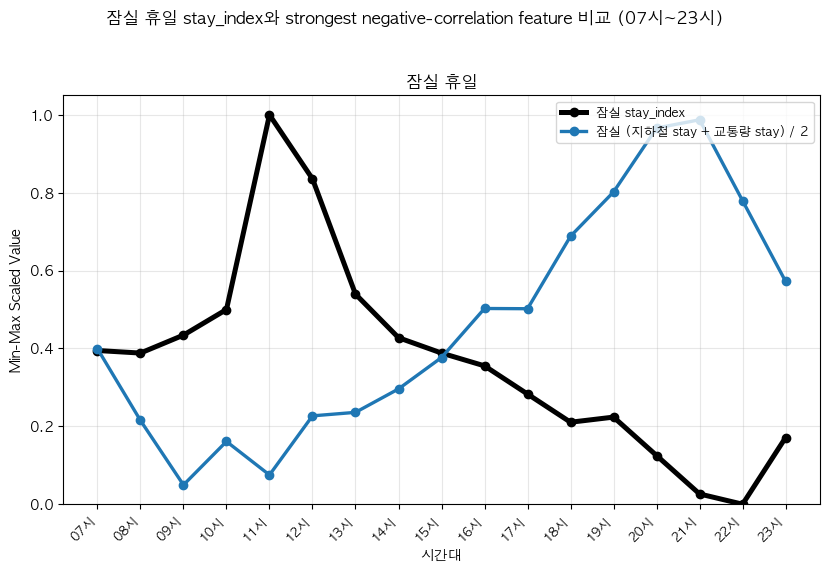

주말 잠실 feature metrics (07시~23시)


,feature_key,feature_label,corr,rmse,mae,r2
0,combined_stay_minmax,잠실 (지하철 stay + 교통량 stay) / 2,-0.811964,0.523546,0.428620,-3.325711
1,subway_stay_minmax,잠실 지하철 stay Min-Max,-0.811876,0.529110,0.429135,-3.418147
2,traffic_stay_minmax,잠실 교통량 stay Min-Max,-0.754482,0.540255,0.445184,-3.606232
3,subway_minmax,잠실 지하철 max Min-Max,0.166182,0.485039,0.416405,-2.712798
4,target_max_minmax,잠실 target max Min-Max,0.210878,0.430725,0.386585,-1.927851
5,combined_minmax,잠실 (지하철 max + 교통량 max) / 2,0.296058,0.467761,0.406128,-2.452994
6,traffic_minmax,잠실 교통량 max Min-Max,0.424130,0.458223,0.401050,-2.313612


잠실 휴일에서 stay_index와 가장 큰 음의 상관을 보인 feature는 잠실 (지하철 stay + 교통량 stay) / 2이며, corr=-0.812, RMSE=0.524, MAE=0.429, R2=-3.326다.


In [4]:
weekend_scaled_feature_meta = {
    feature_key: {"label": meta["label"], "col": meta["col"]}
    for feature_key, meta in feature_meta.items()
    if meta["scaled"]
}

weekend_jamsil_subset = slice_to_plot_hours(jamsil_hourly_stay_index_table, day_type="휴일")
weekend_jamsil_metric_df = build_metric_table(
    weekend_jamsil_subset,
    "stay_index_minmax",
    weekend_scaled_feature_meta,
    corr_ascending=True,
)

selected_weekend_jamsil_feature = weekend_jamsil_metric_df.iloc[0]["feature_key"]
selected_weekend_jamsil_label = weekend_jamsil_metric_df.iloc[0]["feature_label"]
selected_weekend_jamsil_corr = float(weekend_jamsil_metric_df.iloc[0]["corr"])
selected_weekend_jamsil_rmse = float(weekend_jamsil_metric_df.iloc[0]["rmse"])
selected_weekend_jamsil_mae = float(weekend_jamsil_metric_df.iloc[0]["mae"])
selected_weekend_jamsil_r2 = float(weekend_jamsil_metric_df.iloc[0]["r2"])
selected_weekend_jamsil_col = weekend_scaled_feature_meta[selected_weekend_jamsil_feature]["col"]

selected_weekend_baseline_df = weekend_jamsil_subset[["day_type", "hour_label", "hour_order", selected_weekend_jamsil_col]].copy()
selected_weekend_baseline_df = selected_weekend_baseline_df.rename(columns={selected_weekend_jamsil_col: "baseline_scaled"})

fig, ax = plt.subplots(1, 1, figsize=(8.4, 5.8))
line_specs = [
    ("stay_index_minmax", "잠실 stay_index", "black", 3.6),
    (selected_weekend_jamsil_col, selected_weekend_jamsil_label, "#1f77b4", 2.4),
]

x_positions = range(len(plot_hours))

for col, label, color, width in line_specs:
    ax.plot(x_positions, weekend_jamsil_subset[col], marker="o", linewidth=width, color=color, label=label)

ax.set_title("잠실 휴일")
ax.set_xlabel("시간대")
ax.set_ylabel("Min-Max Scaled Value")
ax.set_xticks(list(x_positions))
ax.set_xticklabels(plot_hours, rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9)
fig.suptitle("잠실 휴일 stay_index와 strongest negative-correlation feature 비교 (07시~23시)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("주말 잠실 feature metrics (07시~23시)")
display(weekend_jamsil_metric_df)
print(
    f"잠실 휴일에서 stay_index와 가장 큰 음의 상관을 보인 feature는 {selected_weekend_jamsil_label}이며, "
    f"corr={selected_weekend_jamsil_corr:.3f}, RMSE={selected_weekend_jamsil_rmse:.3f}, "
    f"MAE={selected_weekend_jamsil_mae:.3f}, R2={selected_weekend_jamsil_r2:.3f}다."
)


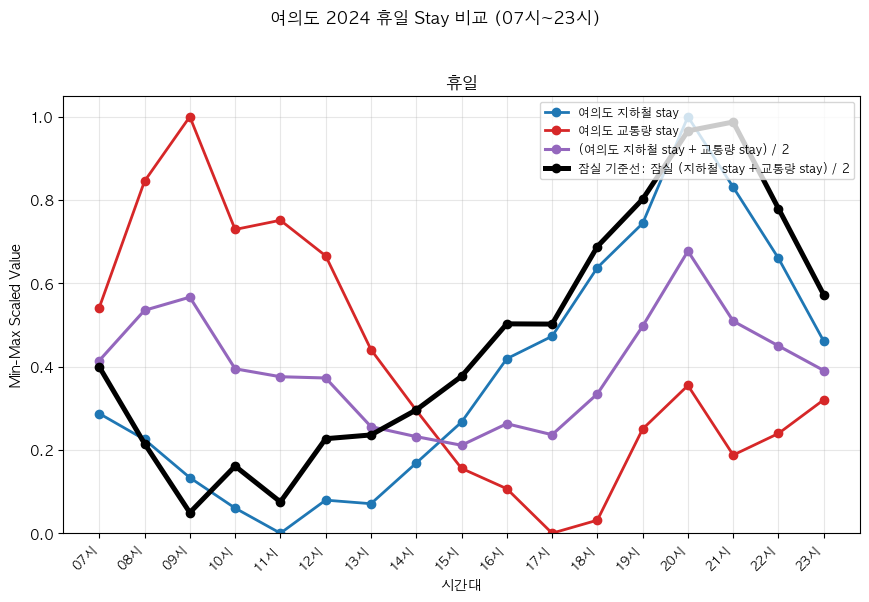

주말 여의도 feature metrics (07시~23시)


,feature_key,feature_label,corr,rmse,mae,r2
0,yeouido_subway_stay,여의도 지하철 stay,0.973591,0.102624,0.092645,0.874736
1,yeouido_combined_stay,여의도 (지하철 stay + 교통량 stay) / 2,0.328610,0.283667,0.248464,0.042923
2,yeouido_traffic_stay,여의도 교통량 stay,-0.691760,0.536716,0.478953,-2.426241


잠실 휴일 기준선은 잠실 (지하철 stay + 교통량 stay) / 2이고, 그 기준선은 stay_index와 corr=-0.812, RMSE=0.524, MAE=0.429, R2=-3.326다.
여의도 휴일에서는 여의도 지하철 stay가 가장 유사하고, corr=0.974, RMSE=0.103, MAE=0.093, R2=0.875다.
그러므로 아마도 여의도 주차장 시간대별 주차장수는 해당 feature로 가중치를 나눌 수 있다.


In [5]:
weekend_yeouido_compare_scaled_df = (
    selected_weekend_baseline_df
    .merge(
        yeouido_hourly_stay_table[[
            "day_type",
            "hour_label",
            "hour_order",
            "yeouido_subway_stay_minmax",
            "yeouido_traffic_stay_minmax",
            "yeouido_combined_minmax",
        ]],
        on=["day_type", "hour_label", "hour_order"],
        how="inner",
    )
    .sort_values(["day_type", "hour_order"])
    .reset_index(drop=True)
)

weekend_yeouido_feature_meta = {
    "yeouido_subway_stay": {"label": "여의도 지하철 stay", "col": "yeouido_subway_stay_minmax"},
    "yeouido_traffic_stay": {"label": "여의도 교통량 stay", "col": "yeouido_traffic_stay_minmax"},
    "yeouido_combined_stay": {"label": "여의도 (지하철 stay + 교통량 stay) / 2", "col": "yeouido_combined_minmax"},
}

weekend_yeouido_subset = slice_to_plot_hours(weekend_yeouido_compare_scaled_df, day_type="휴일")
weekend_yeouido_metric_df = build_metric_table(
    weekend_yeouido_subset,
    "baseline_scaled",
    weekend_yeouido_feature_meta,
    corr_ascending=False,
)

selected_weekend_yeouido_feature = weekend_yeouido_metric_df.iloc[0]["feature_key"]
selected_weekend_yeouido_label = weekend_yeouido_metric_df.iloc[0]["feature_label"]
selected_weekend_yeouido_corr = float(weekend_yeouido_metric_df.iloc[0]["corr"])
selected_weekend_yeouido_rmse = float(weekend_yeouido_metric_df.iloc[0]["rmse"])
selected_weekend_yeouido_mae = float(weekend_yeouido_metric_df.iloc[0]["mae"])
selected_weekend_yeouido_r2 = float(weekend_yeouido_metric_df.iloc[0]["r2"])

fig, ax = plt.subplots(1, 1, figsize=(8.8, 6.1))
line_specs = [
    ("yeouido_subway_stay_minmax", "여의도 지하철 stay", "#1f77b4", 2.0),
    ("yeouido_traffic_stay_minmax", "여의도 교통량 stay", "#d62728", 2.0),
    ("yeouido_combined_minmax", "(여의도 지하철 stay + 교통량 stay) / 2", "#9467bd", 2.2),
    ("baseline_scaled", f"잠실 기준선: {selected_weekend_jamsil_label}", "black", 3.6),
]

x_positions = range(len(plot_hours))

for col, label, color, width in line_specs:
    ax.plot(x_positions, weekend_yeouido_subset[col], marker="o", linewidth=width, color=color, label=label)

ax.set_title("휴일")
ax.set_xlabel("시간대")
ax.set_ylabel("Min-Max Scaled Value")
ax.set_xticks(list(x_positions))
ax.set_xticklabels(plot_hours, rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=8.5)
fig.suptitle("여의도 2024 휴일 Stay 비교 (07시~23시)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("주말 여의도 feature metrics (07시~23시)")
display(weekend_yeouido_metric_df)
print(
    f"잠실 휴일 기준선은 {selected_weekend_jamsil_label}이고, 그 기준선은 stay_index와 "
    f"corr={selected_weekend_jamsil_corr:.3f}, RMSE={selected_weekend_jamsil_rmse:.3f}, "
    f"MAE={selected_weekend_jamsil_mae:.3f}, R2={selected_weekend_jamsil_r2:.3f}다."
)
print(
    f"여의도 휴일에서는 {selected_weekend_yeouido_label}가 가장 유사하고, "
    f"corr={selected_weekend_yeouido_corr:.3f}, RMSE={selected_weekend_yeouido_rmse:.3f}, "
    f"MAE={selected_weekend_yeouido_mae:.3f}, R2={selected_weekend_yeouido_r2:.3f}다."
)
print("그러므로 아마도 여의도 주차장 시간대별 주차장수는 해당 feature로 가중치를 나눌 수 있다.")


### 주말의 경우 여의도 지하철 (1-stay)값을 쓰면 된다.

### 평일 잠실 주차장 입/출 max 기준 비교


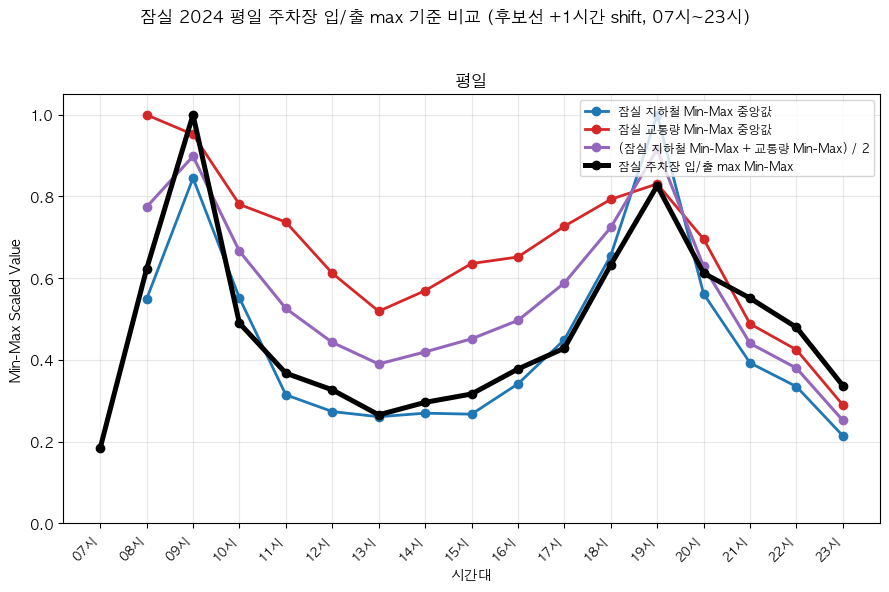

평일 잠실 주차장 입/출 max 기반 metrics (후보선 +1시간 shift, 07시~23시)


,feature_key,feature_label,corr,rmse,mae,r2
0,jamsil_subway_max,잠실 지하철 Min-Max 중앙값,0.924578,0.092952,0.075469,0.808280
1,jamsil_combined_max,잠실 (지하철 Min-Max + 교통량 Min-Max) / 2,0.860521,0.121905,0.116175,0.670243
2,jamsil_traffic_max,잠실 교통량 Min-Max 중앙값,0.645341,0.236548,0.200294,-0.241621


잠실 평일 주차장 입/출 max 기준에서 가장 유사한 feature는 잠실 지하철 Min-Max 중앙값 (1시간 우측 shift 적용)이며, corr=0.925, RMSE=0.093, MAE=0.075, R2=0.808로 세 후보 중 가장 가깝다.


In [6]:
weekday_jamsil_feature_meta = {
    "jamsil_subway_max": {"label": "잠실 지하철 Min-Max 중앙값", "col": "subway_minmax"},
    "jamsil_traffic_max": {"label": "잠실 교통량 Min-Max 중앙값", "col": "traffic_minmax"},
    "jamsil_combined_max": {"label": "잠실 (지하철 Min-Max + 교통량 Min-Max) / 2", "col": "combined_minmax"},
}

weekday_jamsil_subset = slice_to_plot_hours(jamsil_hourly_stay_index_table, day_type="평일")
weekday_jamsil_metric_df = weekday_jamsil_subset.copy()
weekday_jamsil_metric_cols = [meta["col"] for meta in weekday_jamsil_feature_meta.values()]
weekday_jamsil_metric_df[weekday_jamsil_metric_cols] = weekday_jamsil_metric_df[weekday_jamsil_metric_cols].shift(1)
weekday_jamsil_similarity_ranking_df = build_metric_table(
    weekday_jamsil_metric_df,
    "target_max_minmax",
    weekday_jamsil_feature_meta,
    corr_ascending=False,
)

selected_weekday_jamsil_feature = weekday_jamsil_similarity_ranking_df.iloc[0]["feature_key"]
selected_weekday_jamsil_label = weekday_jamsil_similarity_ranking_df.iloc[0]["feature_label"]
selected_weekday_jamsil_corr = float(weekday_jamsil_similarity_ranking_df.iloc[0]["corr"])
selected_weekday_jamsil_rmse = float(weekday_jamsil_similarity_ranking_df.iloc[0]["rmse"])
selected_weekday_jamsil_mae = float(weekday_jamsil_similarity_ranking_df.iloc[0]["mae"])
selected_weekday_jamsil_r2 = float(weekday_jamsil_similarity_ranking_df.iloc[0]["r2"])

selected_weekday_baseline_df = weekday_jamsil_metric_df[["day_type", "hour_label", "hour_order", weekday_jamsil_feature_meta[selected_weekday_jamsil_feature]["col"]]].copy()
selected_weekday_baseline_df = selected_weekday_baseline_df.rename(columns={weekday_jamsil_feature_meta[selected_weekday_jamsil_feature]["col"]: "baseline_scaled"})

fig, ax = plt.subplots(1, 1, figsize=(9.0, 6.0))
line_specs = [
    ("subway_minmax", "잠실 지하철 Min-Max 중앙값", "#1f77b4", 2.0, True),
    ("traffic_minmax", "잠실 교통량 Min-Max 중앙값", "#d62728", 2.0, True),
    ("combined_minmax", "(잠실 지하철 Min-Max + 교통량 Min-Max) / 2", "#9467bd", 2.2, True),
    ("target_max_minmax", "잠실 주차장 입/출 max Min-Max", "black", 3.6, False),
]

x_positions = range(len(plot_hours))
for col, label, color, width, shift_right in line_specs:
    series = weekday_jamsil_metric_df[col] if shift_right else weekday_jamsil_subset[col]
    ax.plot(x_positions, series, marker="o", linewidth=width, color=color, label=label)

ax.set_title("평일")
ax.set_xlabel("시간대")
ax.set_ylabel("Min-Max Scaled Value")
ax.set_xticks(list(x_positions))
ax.set_xticklabels(plot_hours, rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=8.5)
fig.suptitle("잠실 2024 평일 주차장 입/출 max 기준 비교 (후보선 +1시간 shift, 07시~23시)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("평일 잠실 주차장 입/출 max 기반 metrics (후보선 +1시간 shift, 07시~23시)")
display(weekday_jamsil_similarity_ranking_df)
print(
    f"잠실 평일 주차장 입/출 max 기준에서 가장 유사한 feature는 {selected_weekday_jamsil_label} (1시간 우측 shift 적용)이며, "
    f"corr={selected_weekday_jamsil_corr:.3f}, RMSE={selected_weekday_jamsil_rmse:.3f}, "
    f"MAE={selected_weekday_jamsil_mae:.3f}, R2={selected_weekday_jamsil_r2:.3f}로 세 후보 중 가장 가깝다."
)


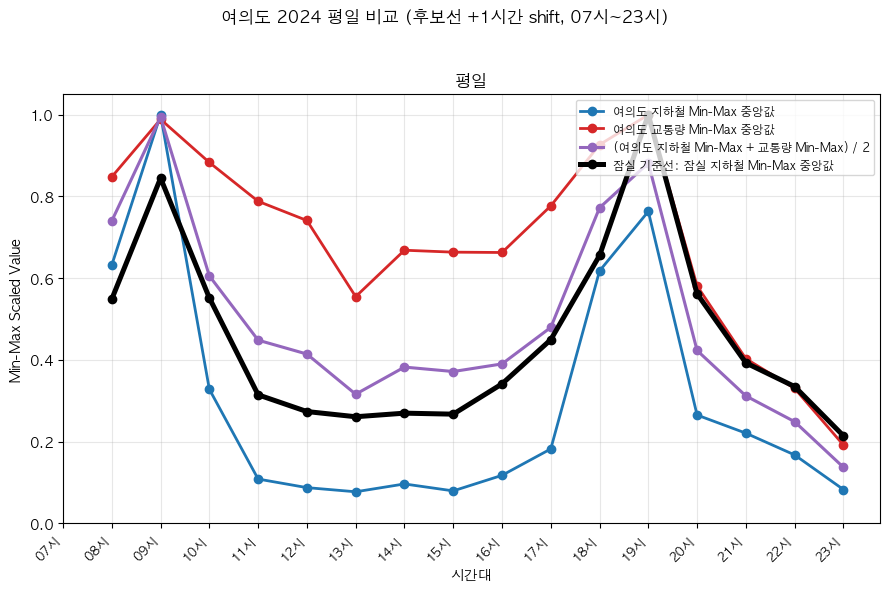

평일 여의도 feature metrics (후보선 +1시간 shift, 07시~23시)


,feature_key,feature_label,corr,rmse,mae,r2
0,yeouido_subway_max,여의도 지하철 Min-Max 중앙값,0.917515,0.193578,0.183331,0.219853
1,yeouido_combined_max,여의도 (지하철 Min-Max + 교통량 Min-Max) / 2,0.896018,0.110779,0.102416,0.744509
2,yeouido_traffic_max,여의도 교통량 Min-Max 중앙값,0.695635,0.290693,0.236475,-0.759272


잠실 평일 기준선은 잠실 지하철 Min-Max 중앙값 (1시간 우측 shift 적용)이고, 잠실 주차장 입/출 max와 corr=0.925, RMSE=0.093, MAE=0.075, R2=0.808로 가장 가깝다.
여의도 평일에서는 여의도 지하철 Min-Max 중앙값 (1시간 우측 shift 적용)가 이 잠실 기준선과 가장 유사하고, corr=0.918, RMSE=0.194, MAE=0.183, R2=0.220다.
그러므로 아마도 여의도 평일 주차장 시간대별 주차장수는 해당 feature로 가중치를 나눌 수 있다.


In [7]:
yeo_subway_max_df = build_max_profile(yeouido_metro_bundle, "yeouido_subway_max")
yeo_traffic_max_df = build_max_profile(yeouido_traffic_bundle, "yeouido_traffic_max")

yeo_subway_max_df = scale_by_day_type(yeo_subway_max_df, "yeouido_subway_max", "yeouido_subway_max_minmax")
yeo_traffic_max_df = scale_by_day_type(yeo_traffic_max_df, "yeouido_traffic_max", "yeouido_traffic_max_minmax")

weekday_yeouido_compare_scaled_df = (
    selected_weekday_baseline_df
    .merge(yeo_subway_max_df[["day_type", "hour_label", "hour_order", "yeouido_subway_max_minmax"]], on=["day_type", "hour_label", "hour_order"], how="inner")
    .merge(yeo_traffic_max_df[["day_type", "hour_label", "hour_order", "yeouido_traffic_max_minmax"]], on=["day_type", "hour_label", "hour_order"], how="inner")
    .sort_values(["day_type", "hour_order"])
    .reset_index(drop=True)
)
weekday_yeouido_compare_scaled_df["yeouido_combined_minmax"] = (
    weekday_yeouido_compare_scaled_df["yeouido_subway_max_minmax"] + weekday_yeouido_compare_scaled_df["yeouido_traffic_max_minmax"]
) / 2

weekday_yeouido_feature_meta = {
    "yeouido_subway_max": {"label": "여의도 지하철 Min-Max 중앙값", "col": "yeouido_subway_max_minmax"},
    "yeouido_traffic_max": {"label": "여의도 교통량 Min-Max 중앙값", "col": "yeouido_traffic_max_minmax"},
    "yeouido_combined_max": {"label": "여의도 (지하철 Min-Max + 교통량 Min-Max) / 2", "col": "yeouido_combined_minmax"},
}

weekday_yeouido_subset = slice_to_plot_hours(weekday_yeouido_compare_scaled_df, day_type="평일")
weekday_yeouido_metric_df = weekday_yeouido_subset.copy()
weekday_yeouido_metric_cols = [meta["col"] for meta in weekday_yeouido_feature_meta.values()]
weekday_yeouido_metric_df[weekday_yeouido_metric_cols] = weekday_yeouido_metric_df[weekday_yeouido_metric_cols].shift(1)
weekday_yeouido_similarity_ranking_df = build_metric_table(
    weekday_yeouido_metric_df,
    "baseline_scaled",
    weekday_yeouido_feature_meta,
    corr_ascending=False,
)

selected_weekday_yeouido_feature = weekday_yeouido_similarity_ranking_df.iloc[0]["feature_key"]
selected_weekday_yeouido_label = weekday_yeouido_similarity_ranking_df.iloc[0]["feature_label"]
selected_weekday_yeouido_corr = float(weekday_yeouido_similarity_ranking_df.iloc[0]["corr"])
selected_weekday_yeouido_rmse = float(weekday_yeouido_similarity_ranking_df.iloc[0]["rmse"])
selected_weekday_yeouido_mae = float(weekday_yeouido_similarity_ranking_df.iloc[0]["mae"])
selected_weekday_yeouido_r2 = float(weekday_yeouido_similarity_ranking_df.iloc[0]["r2"])

fig, ax = plt.subplots(1, 1, figsize=(9.0, 6.0))
line_specs = [
    ("yeouido_subway_max_minmax", "여의도 지하철 Min-Max 중앙값", "#1f77b4", 2.0),
    ("yeouido_traffic_max_minmax", "여의도 교통량 Min-Max 중앙값", "#d62728", 2.0),
    ("yeouido_combined_minmax", "(여의도 지하철 Min-Max + 교통량 Min-Max) / 2", "#9467bd", 2.2),
    ("baseline_scaled", f"잠실 기준선: {selected_weekday_jamsil_label}", "black", 3.6),
]

x_positions = range(len(plot_hours))
for col, label, color, width in line_specs:
    series = weekday_yeouido_metric_df[col] if col != "baseline_scaled" else weekday_yeouido_subset[col]
    ax.plot(x_positions, series, marker="o", linewidth=width, color=color, label=label)

ax.set_title("평일")
ax.set_xlabel("시간대")
ax.set_ylabel("Min-Max Scaled Value")
ax.set_xticks(list(x_positions))
ax.set_xticklabels(plot_hours, rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=8.3)
fig.suptitle("여의도 2024 평일 비교 (후보선 +1시간 shift, 07시~23시)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("평일 여의도 feature metrics (후보선 +1시간 shift, 07시~23시)")
display(weekday_yeouido_similarity_ranking_df)
print(
    f"잠실 평일 기준선은 {selected_weekday_jamsil_label} (1시간 우측 shift 적용)이고, 잠실 주차장 입/출 max와 "
    f"corr={selected_weekday_jamsil_corr:.3f}, RMSE={selected_weekday_jamsil_rmse:.3f}, "
    f"MAE={selected_weekday_jamsil_mae:.3f}, R2={selected_weekday_jamsil_r2:.3f}로 가장 가깝다."
)
print(
    f"여의도 평일에서는 {selected_weekday_yeouido_label} (1시간 우측 shift 적용)가 이 잠실 기준선과 가장 유사하고, "
    f"corr={selected_weekday_yeouido_corr:.3f}, RMSE={selected_weekday_yeouido_rmse:.3f}, "
    f"MAE={selected_weekday_yeouido_mae:.3f}, R2={selected_weekday_yeouido_r2:.3f}다."
)
print("그러므로 아마도 여의도 평일 주차장 시간대별 주차장수는 해당 feature로 가중치를 나눌 수 있다.")


### 평일의 경우 (지하철 min-max + 교통량 min+max)/2의 stay값을 가중치로 쓰면 된다

In [8]:
import json

required_vars = ["yeo_subway_max_df", "yeo_traffic_max_df"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise NameError(f"Run previous Yeouido comparison cells first: {missing_vars}")

weight_hours = [f"{hour:02d}시" for hour in range(7, 23)]
weight_hour_keys = [hour.replace("시", "") for hour in weight_hours]

target_raw_df = pd.read_csv(project_root / "Data/jamsil_Target_2024.csv")
time_col = pick_column(target_raw_df.columns, ["시간대"])
capacity_col = pick_column(target_raw_df.columns, ["주차면수"])
in_col = pick_column(target_raw_df.columns, ["입차"])
out_col = pick_column(target_raw_df.columns, ["출차"])

target_raw_df["timestamp"] = pd.to_datetime(target_raw_df[time_col], errors="coerce")
if target_raw_df["timestamp"].isna().any():
    target_raw_df["timestamp"] = pd.to_datetime(
        target_raw_df[time_col].astype(str), format="%Y-%m-%d %H", errors="coerce"
    )

target_raw_df = target_raw_df.dropna(subset=["timestamp"]).copy()
target_raw_df["date"] = target_raw_df["timestamp"].dt.normalize()
target_raw_df["day_type"] = label_day_type(target_raw_df["date"])
target_raw_df["hour_order"] = target_raw_df["timestamp"].dt.hour
target_raw_df["hour_label"] = target_raw_df["hour_order"].map(lambda hour: f"{hour:02d}시")
target_raw_df[[capacity_col, in_col, out_col]] = target_raw_df[[capacity_col, in_col, out_col]].apply(pd.to_numeric, errors="coerce").fillna(0)

target_hourly_07_22_df = (
    target_raw_df[target_raw_df["hour_order"].between(7, 22)]
    .groupby(["date", "day_type", "hour_label", "hour_order"], as_index=False)[[capacity_col, in_col, out_col]]
    .agg({capacity_col: "max", in_col: "sum", out_col: "sum"})
    .sort_values(["date", "hour_order"])
    .reset_index(drop=True)
)

weekday_daily_parts = []
for date_value, group in target_hourly_07_22_df[target_hourly_07_22_df["day_type"] == "평일"].groupby("date", sort=False):
    day_group = group.sort_values("hour_order").copy()
    capacity = float(day_group[capacity_col].iloc[0])
    available_count = capacity
    availability_ratio = []

    for _, row in day_group.iterrows():
        if int(row["hour_order"]) == 7:
            available_count = capacity
        else:
            available_count = available_count + float(row[out_col]) - float(row[in_col])
            available_count = min(max(available_count, 0.0), capacity)
        availability_ratio.append(available_count / capacity if capacity else 0.0)

    day_group["weekday_availability_ratio"] = availability_ratio
    weekday_daily_parts.append(day_group)

weekday_availability_daily_df = pd.concat(weekday_daily_parts, ignore_index=True)
weekday_weight_df = (
    weekday_availability_daily_df
    .groupby(["day_type", "hour_label", "hour_order"], as_index=False)["weekday_availability_ratio"]
    .median()
    .sort_values("hour_order")
    .reset_index(drop=True)
)
weekday_weight_df["hour_key"] = weekday_weight_df["hour_label"].str.replace("시", "", regex=False)
weekday_weight_df["weight_source"] = weekday_weight_df["weekday_availability_ratio"]
weekday_weight_df["weight"] = weekday_weight_df["weekday_availability_ratio"]
weekday_weight_df["basis"] = "parking_availability_ratio_reset_at_07"

holiday_weight_df = (
    yeo_subway_max_df[["day_type", "hour_label", "hour_order", "yeouido_subway_max_minmax"]]
    .copy()
)
holiday_weight_df = holiday_weight_df[
    (holiday_weight_df["day_type"] == "휴일") & (holiday_weight_df["hour_label"].isin(weight_hours))
].sort_values("hour_order").reset_index(drop=True)
holiday_weight_df["hour_key"] = holiday_weight_df["hour_label"].str.replace("시", "", regex=False)
holiday_weight_df["weight_source"] = 1 - holiday_weight_df["yeouido_subway_max_minmax"]
holiday_weight_df["weight"] = minmax_scale(holiday_weight_df["weight_source"])
holiday_weight_df["basis"] = "1 - subway_minmax"

yeouido_weight_final_df = pd.concat([
    weekday_weight_df[["day_type", "hour_label", "hour_order", "hour_key", "basis", "weight_source", "weight"]],
    holiday_weight_df[["day_type", "hour_label", "hour_order", "hour_key", "basis", "weight_source", "weight"]],
], ignore_index=True).sort_values(["day_type", "hour_order"]).reset_index(drop=True)

day_type_map = {"평일": "weekday", "휴일": "holiday"}
existing_day_types = set(yeouido_weight_final_df["day_type"].unique())
required_day_types = {"평일", "휴일"}
if existing_day_types != required_day_types:
    raise ValueError(f"Expected both 평일 and 휴일, got {sorted(existing_day_types)}")

for day_type in ["평일", "휴일"]:
    day_subset = yeouido_weight_final_df[yeouido_weight_final_df["day_type"] == day_type].sort_values("hour_order")
    if day_subset["hour_key"].tolist() != weight_hour_keys:
        raise ValueError(f"Hour alignment mismatch for {day_type}: {day_subset['hour_key'].tolist()}")
    if day_subset["weight"].isna().any():
        raise ValueError(f"NaN detected in final weights for {day_type}")

weight_json = {
    "metadata": {
        "location": "yeouido",
        "base": "2024",
        "hours": weight_hour_keys,
        "weekday_basis": "parking_availability_ratio_reset_at_07",
        "holiday_basis": "1 - subway_minmax",
    },
    "weights": {
        day_type_map[day_type]: {
            hour: float(day_subset.loc[day_subset["hour_key"] == hour, "weight"].iloc[0])
            for hour in weight_hour_keys
        }
        for day_type, day_subset in (
            (day_type, yeouido_weight_final_df[yeouido_weight_final_df["day_type"] == day_type].sort_values("hour_order"))
            for day_type in ["평일", "휴일"]
        )
    },
}

weight_output_path = project_root / "Data/yeouido_weights_2024.json"
weight_output_path.write_text(json.dumps(weight_json, ensure_ascii=False, indent=2), encoding="utf-8")

print("yeouido weight dataframe")
display(yeouido_weight_final_df)
print("json preview")
print(json.dumps(weight_json, ensure_ascii=False, indent=2))
print(f"saved to: {weight_output_path}")


yeouido weight dataframe


,day_type,hour_label,hour_order,hour_key,basis,weight_source,weight
0,평일,07시,7,07,parking_availability_ratio_reset_at_07,1.000000,1.000000
1,평일,08시,8,08,parking_availability_ratio_reset_at_07,0.834734,0.834734
2,평일,09시,9,09,parking_availability_ratio_reset_at_07,0.554622,0.554622
3,평일,10시,10,10,parking_availability_ratio_reset_at_07,0.434174,0.434174
4,평일,11시,11,11,parking_availability_ratio_reset_at_07,0.358543,0.358543
5,평일,12시,12,12,parking_availability_ratio_reset_at_07,0.310924,0.310924
6,평일,13시,13,13,parking_availability_ratio_reset_at_07,0.302521,0.302521
7,평일,14시,14,14,parking_availability_ratio_reset_at_07,0.305322,0.305322
8,평일,15시,15,15,parking_availability_ratio_reset_at_07,0.308123,0.308123
9,평일,16시,16,16,parking_availability_ratio_reset_at_07,0.330532,0.330532


json preview
{
  "metadata": {
    "location": "yeouido",
    "base": "2024",
    "hours": [
      "07",
      "08",
      "09",
      "10",
      "11",
      "12",
      "13",
      "14",
      "15",
      "16",
      "17",
      "18",
      "19",
      "20",
      "21",
      "22"
    ],
    "weekday_basis": "parking_availability_ratio_reset_at_07",
    "holiday_basis": "1 - subway_minmax"
  },
  "weights": {
    "weekday": {
      "07": 1.0,
      "08": 0.834733893557423,
      "09": 0.5546218487394958,
      "10": 0.4341736694677871,
      "11": 0.3585434173669468,
      "12": 0.31092436974789917,
      "13": 0.3025210084033613,
      "14": 0.30532212885154064,
      "15": 0.3081232492997199,
      "16": 0.33053221288515405,
      "17": 0.36694677871148457,
      "18": 0.46218487394957986,
      "19": 0.6022408963585434,
      "20": 0.7030812324929971,
      "21": 0.8207282913165266,
      "22": 0.9355742296918768
    },
    "holiday": {
      "07": 1.0,
      "08": 0.8268210323203